In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats


In [2]:
param_file = "/Users/vilasini/Documents/WALE/data/selected_params_halofit_unique.npy"
param_table = np.load(param_file)
param_table

from typing import Dict, Any

PARAM_NAMES = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

def load_cosmology_from_param_table(param_file: str, cosmo_index: int = 0) -> Dict[str, Any]:
    """
    Load cosmology parameters from a numpy file and return a dict of standard names.

    Supports:
    - numeric 2D arrays of shape (n_samples, 6)
    - numeric 1D arrays of length 6 (single sample)
    - structured numpy arrays with named fields (will attempt to map by PARAM_NAMES)

    Returned keys:
    - h, Oc (Omega_c), Ob (Omega_b), w (w0), wa, sigma8, Om, ns, H0
    """
    data = np.load(param_file, allow_pickle=True)

    # Structured dtype with names?
    if hasattr(data, "dtype") and data.dtype.names:
        # Try to map by latex labels or common equivalents
        def get_field(name_candidates):
            for nm in name_candidates:
                if nm in data.dtype.names:
                    return data[nm][cosmo_index] if data.ndim > 0 else data[nm].item()
            return None

        # common possible field names to check
        candidates = {
            "Omega_m": [r"$\\Omega_{m}$", "Omega_m", "Om", "omega_m", "omegam"],
            "sigma8": [r"$\\sigma_8$", "sigma8", "s8"],
            "w0": [r"$w_0$", "w0", "w"],
            "H0": [r"$H_0$", "H0", "h0"],
            "ns": [r"$n_s$", "ns"],
            "Omega_b": [r"$\\Omega_b$", "Omega_b", "Ob", "omegab"],
        }

        Omega_m = get_field(candidates["Omega_m"])
        sigma8 = get_field(candidates["sigma8"])
        w0 = get_field(candidates["w0"])
        H0 = get_field(candidates["H0"])
        ns = get_field(candidates["ns"])
        Omega_b = get_field(candidates["Omega_b"])

    else:
        # Numeric array: accept 1D length-6 or 2D samples x 6
        arr = np.asarray(data)
        if arr.ndim == 1 and arr.size == 6:
            row = arr
        elif arr.ndim == 2 and arr.shape[1] == 6:
            row = arr[cosmo_index]
        else:
            raise ValueError(f"Unexpected shape for param_table: {arr.shape}. Expect (6,) or (N,6).")

        Omega_m, sigma8, w0, H0, ns, Omega_b = row

    # Convert / compute standard quantities
    H0 = float(H0)
    h = H0 / 100.0
    Om = float(Omega_m)
    Ob = float(Omega_b)
    Oc = Om - Ob             # cold dark matter density
    w = float(w0)
    wa = 0.0                  # default unless present in table
    sigma8 = float(sigma8)
    ns = float(ns)

    return {
        "h": h,
        "Oc": Oc,
        "Ob": Ob,
        "w": w,
        "wa": wa,
        "sigma8": sigma8,
        "Om": Om,
        "ns": ns,
        "H0": H0,
    }

# Example usage:
# param_file = "/path/to/selected_params_halofit_unique.npy"
# params = load_cosmology_from_param_table(param_file, cosmo_index=5)
# h = params["h"]; Oc = params["Oc"]; Ob = params["Ob"]; ...

In [52]:
cosmogrid_kappa = np.load("../data/all_kappas_halofit_nobaryons_bin4_theta20.0.npy")
cosmogrid_l1norms = np.load("../data/all_l1_norms_halofit_nobaryons_bin4_theta20.0.npy")
cosmogrid_variances = np.load("../data/all_variances_halofit_nobaryons_bin4_theta20.0.npy")

cosmogrid_params = np.load("../data/selected_params_halofit.npy")

cosmogrid_kappa = np.load("../data/all_kappas_halofit_nobaryons_bin4.npy")
cosmogrid_l1norms = np.load("../data/all_l1_norms_halofit_nobaryons_bin4.npy")
cosmogrid_variances = np.load("../data/all_variances_halofit_nobaryons_bin4.npy")

cosmogrid_kappa = np.load("../data/all_kappas_fiducial_nobaryons_bin4_theta30.0.npy")
cosmogrid_l1norms = np.load("../data/all_l1_norms_fiducial_nobaryons_bin4_theta30.0.npy")
cosmogrid_variances = np.load("../data/all_variances_fiducial_nobaryons_bin4_theta30.0.npy")
cosmogrid_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

cosmogrid_snr = cosmogrid_kappa / (cosmogrid_variances[:, np.newaxis] ** 0.5)

print(cosmogrid_kappa.shape, cosmogrid_l1norms.shape, cosmogrid_variances.shape, cosmogrid_params.shape, cosmogrid_snr.shape)

id_zbin = 3  # Corresponds to the third redshift bin
nz_file = f"/Users/vilasini/Documents/WALE/data/nz/nz_stage3_{id_zbin+1}_GRID.txt"
print(f"Using n(z) file: {nz_file}")
theta1_input = 30.0  # Smoothing scale in arcmin
filter_type = 'tophat'

invalid_index = []
predictionl1 = []
predictionl1snr = []
cosmogrid=True


params = cosmogrid_params        # shape (1299, 6)

# find unique cosmologies
unique_params, inv = np.unique(params, axis=0, return_inverse=True)

# inv is an array of length 1299 giving the group number (0..185)
# Build a list of index groups
groups = [np.where(inv == i)[0] for i in range(len(unique_params))]
n_cosmo = len(groups)  # = 186

print(f"Found {n_cosmo} unique cosmologies from {len(params)} total realizations.")

kappa_fix = np.linspace(-0.03, 0.03, 400)
snr_fix   = np.linspace(-4,  4,   300)

cosmogrid_l1norm_mean_kappa = []
cosmogrid_l1norm_mean_snr   = []
cosmogrid_l1norm_std_kappa  = []
cosmogrid_l1norm_std_snr    = []
cosmogrid_variance_mean     = []
cosmogrid_variance_std      = []
cosmogrid_interp_l1_kappa = []
cosmogrid_interp_l1_snr = []
for idx in groups:
    # idx = list of rows belonging to one cosmology
    l1_group = cosmogrid_l1norms[idx]      # shape (n_real, Nkappa)
    k_group  = cosmogrid_kappa[idx]        # same shape
    snr_group = cosmogrid_snr[idx]         # same shape
    var_group = cosmogrid_variances[idx]   # shape (n_real,)

    # interpolate each realisation to fixed kappa grid
    interp_kappa = np.array([
        np.interp(kappa_fix, k_group[j], l1_group[j])
        for j in range(len(idx))
    ])

    # interpolate each realisation to fixed snr grid
    interp_snr = np.array([
        np.interp(snr_fix, snr_group[j], l1_group[j])
        for j in range(len(idx))
    ])

    # mean across realisations for this cosmology
    cosmogrid_l1norm_mean_kappa.append(interp_kappa.mean(axis=0))
    cosmogrid_l1norm_mean_snr.append(interp_snr.mean(axis=0))
    cosmogrid_l1norm_std_kappa.append(interp_kappa.std(axis=0))
    cosmogrid_l1norm_std_snr.append(interp_snr.std(axis=0))
    cosmogrid_variance_mean.append(var_group.mean())
    cosmogrid_variance_std.append(var_group.std())
    cosmogrid_interp_l1_kappa.append(interp_kappa)
    cosmogrid_interp_l1_snr.append(interp_snr)

# convert to arrays (shape: n_cosmo × grid size)
cosmogrid_l1norm_mean_kappa = np.array(cosmogrid_l1norm_mean_kappa)
cosmogrid_l1norm_mean_snr   = np.array(cosmogrid_l1norm_mean_snr)
cosmogrid_variance_mean     = np.array(cosmogrid_variance_mean)
cosmogrid_l1norm_std_kappa  = np.array(cosmogrid_l1norm_std_kappa)
cosmogrid_l1norm_std_snr    = np.array(cosmogrid_l1norm_std_snr)
cosmogrid_variance_std      = np.array(cosmogrid_variance_std)
cosmogrid_interp_l1_kappa = np.array(cosmogrid_interp_l1_kappa)
cosmogrid_interp_l1_snr = np.array(cosmogrid_interp_l1_snr)

n_cosmo

(200, 500) (200, 500) (200,) (1, 6) (200, 500)
Using n(z) file: /Users/vilasini/Documents/WALE/data/nz/nz_stage3_4_GRID.txt
Found 1 unique cosmologies from 1 total realizations.


1

In [53]:
from joblib import Parallel, delayed
import warnings
import numpy as np
from scipy.interpolate import CubicSpline

# ----------------------------------------------------------
# Fixed grids
# ----------------------------------------------------------

def process_unique_cosmology(cosmo_id):
    warnings.filterwarnings("ignore",
                        message="invalid value encountered in sqrt",
                        category=RuntimeWarning)

    warnings.filterwarnings("ignore",   
                        message="invalid value encountered in power",
                        category=RuntimeWarning)


    # ------------------------------------------------------
    # Group indices for this cosmology
    # ------------------------------------------------------
    real_indices = np.where(inv == cosmo_id)[0]
    print(f"[Cosmo {cosmo_id}] {len(real_indices)} realizations")

    # ------------------------------------------------------
    # Cosmology parameters
    # ------------------------------------------------------
    Om, sigma8, w, h100, ns, Ob = unique_params[cosmo_id]
    h  = h100 / 100.
    Oc = Om - Ob
    wa = 0.0

    # ------------------------------------------------------
    # 1) USE **ONLY COSMOGRID MEAN VARIANCE**
    # ------------------------------------------------------
    variance_mean = cosmogrid_variance_mean[cosmo_id]

    # ------------------------------------------------------
    # Representative realization values (ONLY for shape)
    # ------------------------------------------------------
    # rep_idx = real_indices[0]
    kappa_rep = kappa_fix #cosmogrid_kappa[rep_idx]      # x-axis for empirical curves
    snr_rep   = snr_fix #cosmogrid_snr[rep_idx]

    # ------------------------------------------------------
    # 2) Build LDT variables
    # ------------------------------------------------------
    

    variables = InitialiseVariables(
        h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
        dk=0.01, kmin=1e-3, kmax=3.,
        nz_file=nz_file, variability=False,
        theta1=theta1_input, nplanes=20, ns=ns
    )


    pks = variables.cosmo.pnl
    redshifts = variables.redshifts
    print("the shape of pk:", pks.keys())
    print("the redshifts:", redshifts)
    ell = np.arange(2, 20000)
    # cls = ccl.angular_cl(variables.cosmo, pks, ell)

    # Compute theory σ²
    variance = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)
    variables.sigmasq_map = np.sum(
        variables.dchi * (variables.lensingweights**2) *
        np.array([
            variance.get_sig_slice(z, chi * variables.theta1_radian,
                                      chi * variables.theta2_radian)
            for z, chi in zip(variables.redshifts, variables.chis)
        ])
    )

    theory_sigmasq = compute_sigma_kappa_squared(
        theta1_input, variables.chis, variables.lensingweights,
        variables.redshifts, variables.cosmo.k, variables.cosmo.pnl,
        filter_type=filter_type, h=h
    )

    # ------------------------------------------------------
    # Recalibrate theory using cosmogrid **mean variance**
    # ------------------------------------------------------
    variables.recal_value = variables.sigmasq_map / variance_mean

    print("the perturb variance:", theory_sigmasq)
    print("the ldt variance:", variables.sigmasq_map)
    print("the sim variance:", variance_mean)
    print("recalibration factor:", variables.recal_value)
    # ------------------------------------------------------
    # 3) Compute theory PDF(kappa)
    # ------------------------------------------------------
    smallest_positive, largest_negative = find_critical_points_for_cosmo(
        variables, variance, ngrid_critical=20,
        plot=False, min_z=0, max_z=5
    )

    if smallest_positive and largest_negative is not None:
        variables.lambdas = np.linspace(largest_negative,
                                        smallest_positive, 20)

    computed_PDF = computePDF(variables, variance,
                              plot_scgf=False,
                              kappa=kappa_rep)

    kappa_vals = computed_PDF.kappa_values
    pdf_vals   = computed_PDF.pdf_values
    pdf_vals = np.array(pdf_vals)
    pred_stats = get_moments(kappa_vals, pdf_vals)
    print(f"  predstats: mean: {pred_stats[0]}, variance: {pred_stats[1]}, s3: {pred_stats[2]:.3f}, kurtosis: {pred_stats[3]:.3f}, norm: {pred_stats[4]:.3f}") 

    # ------------------------------------------------------
    # 4) THEORY L1-norm vs kappa, snr
    # ------------------------------------------------------
    theory_l1_kappa = np.abs(kappa_vals) * pdf_vals

    norm_kappa = kappa_vals / np.sqrt(theory_sigmasq)
    theory_l1_snr = CubicSpline(norm_kappa, theory_l1_kappa)(snr_fix)

    # Interpolate theory to FIXED GRIDS
    theory_l1_kappa_fix = np.interp(kappa_fix, kappa_vals, theory_l1_kappa)

    # ------------------------------------------------------
    # 5) COSMOGRID MEAN CURVES ALREADY PRE-COMPUTED
    # ------------------------------------------------------
    cg_l1_mean_kappa = cosmogrid_l1norm_mean_kappa[cosmo_id]  # same shape as kappa_fix
    cg_l1_mean_snr   = cosmogrid_l1norm_mean_snr[cosmo_id]    # same shape as snr_fix
    cg_l1_std_kappa = cosmogrid_l1norm_std_kappa[cosmo_id]
    cg_l1_std_snr   = cosmogrid_l1norm_std_snr[cosmo_id]
    cg_var_mean      = cosmogrid_variance_mean[cosmo_id]
    cg_var_std      = cosmogrid_variance_std[cosmo_id]

    return {
        "cosmo_id": cosmo_id,
        "params": {
            "Om": Om, "sigma8": sigma8, "w": w,
            "h": h, "ns": ns, "Ob": Ob, "Oc": Oc, "wa": wa
        },
        

        # ----------------------------------------------------------
        # FIXED X-AXES
        # ----------------------------------------------------------
        "kappa_fix": kappa_fix,
        "snr_fix": snr_fix,

        # ----------------------------------------------------------
        # THEORY RESULTS
        # ----------------------------------------------------------
        "theory_l1_kappa_fix": theory_l1_kappa_fix,
        "theory_l1_snr_fix":  theory_l1_snr,
        "pred_stats": pred_stats,

        # ----------------------------------------------------------
        # COSMOGRID EMPIRICAL MEANS (precomputed)
        # ----------------------------------------------------------
        "cg_l1_kappa_mean": cg_l1_mean_kappa,
        "cg_l1_snr_mean":   cg_l1_mean_snr,
        "cg_variance_mean": cg_var_mean,
        "cg_variance_std":      cg_var_std,
        "cg_l1_kappa_std":      cg_l1_std_kappa,
        "cg_l1_snr_std":        cg_l1_std_snr,
        "cg_l1_kappa_realizations": cosmogrid_interp_l1_kappa[cosmo_id],
        "cg_l1_snr_realizations": cosmogrid_interp_l1_snr[cosmo_id],
    }


In [54]:

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="invalid value encountered in power")
    
    # --- call the part that triggers the warning ---
    results = Parallel(n_jobs=8, verbose=10)(
        delayed(process_unique_cosmology)(cosmo_id)
        for cosmo_id in range(n_cosmo)
    )


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


[Cosmo 0] 1 realizations

Initialised Cosmology:
  h = 0.6736, Oc = 0.2107, Ob = 0.0493, w = -1.0, wa = 0.0, sigma8 = 0.84
  k-range: [0.001, 3.0] with step dk = 0.01

      Variability: disabled
the shape of pk: dict_keys([np.float64(4.348454770580225), np.float64(3.7959842261346686), np.float64(3.323134885505074), np.float64(2.9149546619180042), np.float64(2.5597858683059065), np.float64(2.248432322892641), np.float64(1.9735552721026157), np.float64(1.7292348467800291), np.float64(1.5106496665696436), np.float64(1.3138406435123062), np.float64(1.1355217942357736), np.float64(0.9729541397621752), np.float64(0.8238267859182657), np.float64(0.6861833300485186), np.float64(0.5583581203133062), np.float64(0.43891533057510346), np.float64(0.32662021695436383), np.float64(0.22039969080578048), np.float64(0.11932224168643468), np.float64(0.022570063391832568)])
the redshifts: [0.02257006 0.11932224 0.22039969 0.32662022 0.43891533 0.55835812
 0.68618333 0.82382679 0.97295414 1.13552179 1.313

[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:   10.1s


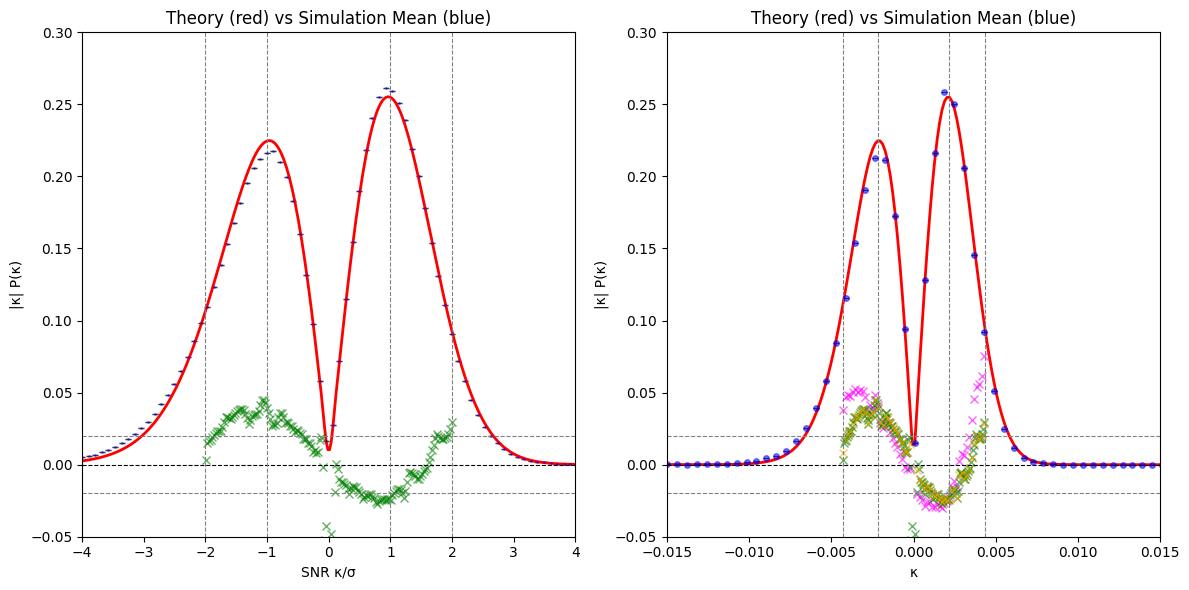

invalid predictions: 0


In [55]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
counter = 0

for r in results:

    cosmo_id = r["cosmo_id"]

    # Fixed axes
    kappa_fix = r["kappa_fix"]
    snr_fix   = r["snr_fix"]

    # THEORY
    th_l1_kappa = r["theory_l1_kappa_fix"]
    th_l1_snr   = r["theory_l1_snr_fix"]

    # SIMULATION (mean across realizations)
    cg_l1_kappa_mean = r["cg_l1_kappa_mean"]
    cg_l1_kappa_std  = r["cg_l1_kappa_std"]
    cg_l1_snr_mean   = r["cg_l1_snr_mean"]
    cg_l1_snr_std    = r["cg_l1_snr_std"]


    cg_var_mean = r["cg_variance_mean"]
    sigma = np.sqrt(cg_var_mean)
    # if np.any(th_l1_snr <0):
    #     print(f"Skipping invalid cosmology {cosmo_id}")
    #     continue
    # check theory validity
    if np.any(th_l1_snr < -1e-3):
        print(f"Skipping invalid cosmology {cosmo_id}")
        print(r["params"])
        counter += 1
        continue

    # -------------------------------------------------------------
    # PLOT: SNR domain
    # -------------------------------------------------------------
    # Theory
    

    # Simulation mean (no need for std here)
    ax[0].errorbar(snr_fix[::4], cg_l1_snr_mean[::4], yerr=cg_l1_snr_std[::4], fmt='o', ms=1, color='blue', alpha=0.5, label=cosmo_id, capsize=2, ecolor='black')
    ax[0].plot(snr_fix, th_l1_snr, 'r-', lw=2)

    # Residuals (theory - simulation) / simulation
    residual_snr = (th_l1_snr - cg_l1_snr_mean) / (cg_l1_snr_mean + 1e-12)

    mask_snr = (snr_fix > -2) & (snr_fix < 2)
    ax[0].plot(snr_fix[mask_snr], residual_snr[mask_snr],
               'x', color='green', alpha=0.6)

    # -------------------------------------------------------------
    # PLOT: kappa domain
    # -------------------------------------------------------------
    # Theory
    ax[1].plot(kappa_fix, th_l1_kappa, 'r-', lw=2)

    # Simulation mean
    
    ax[1].errorbar(kappa_fix[::4], cg_l1_kappa_mean[::4], yerr=cg_l1_kappa_std[::4], fmt='o', ms=4, color='blue', alpha=0.5, label=cosmo_id, capsize=2, ecolor='black')

    # Residuals
    residual_kappa = (th_l1_kappa - cg_l1_kappa_mean) / (cg_l1_kappa_mean + 1e-12)
    mask_k = (kappa_fix > -2.*sigma) & (kappa_fix < 2.*sigma)
#
    ax[1].plot(kappa_fix[mask_k], residual_kappa[mask_k],
               'x', color='magenta', alpha=0.6)
    ax[1].plot(snr_fix[mask_snr]*sigma, residual_snr[mask_snr],
               'x', color='green', alpha=0.6)
    residual_spline_snr = CubicSpline(snr_fix[mask_snr]*sigma, residual_snr[mask_snr])(kappa_fix[mask_k])
    ax[1].plot(kappa_fix[mask_k], residual_spline_snr,
               'x', color='orange', alpha=0.6)

# -------------------------------------------------------------
# Figure formatting
# -------------------------------------------------------------
ax[0].set_xlabel("SNR κ/σ")
ax[0].set_ylabel("|κ| P(κ)")
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_title("Theory (red) vs Simulation Mean (blue)")
ax[0].axhline(0, color='black', lw=0.8, ls='--')
ax[0].axhline(0.02, color='gray', lw=0.8, ls='--')
ax[0].axhline(-0.02, color='gray', lw=0.8, ls='--')
ax[0].axvline(-2, color='gray', lw=0.8, ls='--')
ax[0].axvline(2, color='gray', lw=0.8, ls='--')
ax[0].axvline(-1, color='gray', lw=0.8, ls='--')
ax[0].axvline(1, color='gray', lw=0.8, ls='--')
ax[1].set_xlabel("κ")
ax[1].set_ylabel("|κ| P(κ)")
ax[1].set_xlim(-0.015, 0.015)
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_title("Theory (red) vs Simulation Mean (blue)")
ax[1].axhline(0, color='black', lw=0.8, ls='--')
ax[1].axhline(0.02, color='gray', lw=0.8, ls='--')
ax[1].axhline(-0.02, color='gray', lw=0.8, ls='--')
ax[1].axvline(-2*sigma, color='gray', lw=0.8, ls='--')
ax[1].axvline(2*sigma, color='gray', lw=0.8, ls='--')
ax[1].axvline(-1*sigma, color='gray', lw=0.8, ls='--')
ax[1].axvline(1*sigma, color='gray', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

print("invalid predictions:", counter)


In [56]:
np.savez(
    "cosmo_parallel_results_bin4_fiducial_theta30.npz",
    results=results
)

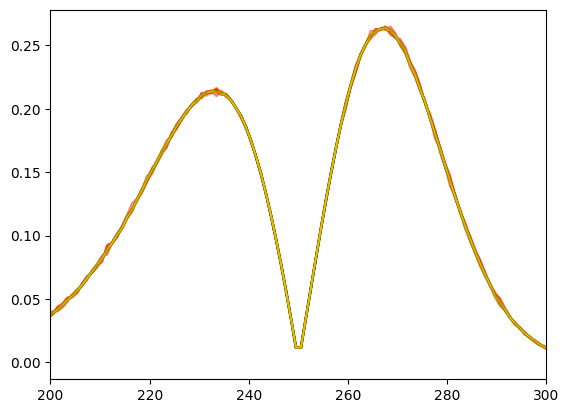

(200.0, 300.0)

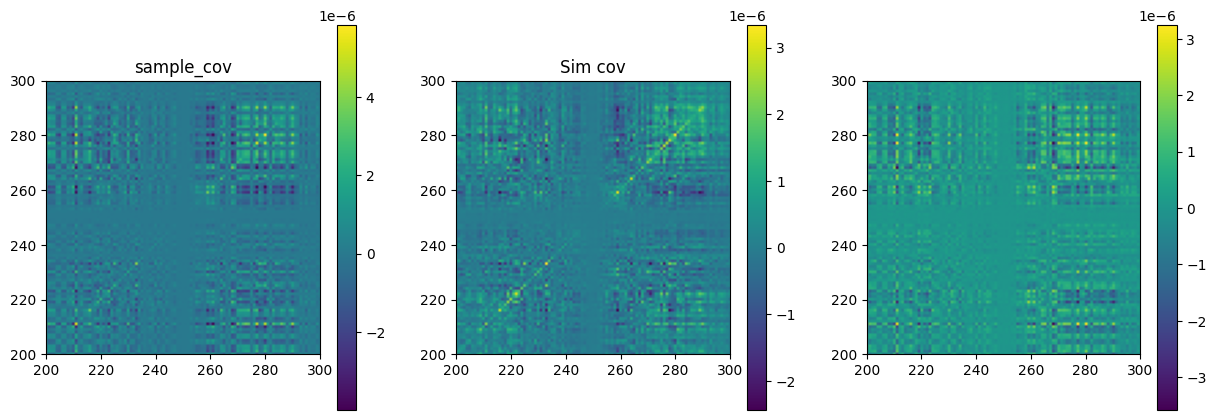

In [123]:
import numpy as np

# mean: shape (d,)
mu = mean_l1

# covariance: shape (d, d), full (non-diagonal) matrix
Sigma = l1_cov

n_samples = 10  # or however many data vectors you want

samples = np.random.multivariate_normal(mean=mu, cov=Sigma, size=n_samples)

plt.plot(x,samples.T,c='r',alpha=0.5)
plt.plot(x,mu, 'k', lw=2, alpha=0.8)
plt.plot(x,l1s,c="yellow",alpha=0.2)
plt.xlim(200,300)
plt.show()

sample_cov = np.cov(samples.T)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(sample_cov, origin='lower')
plt.xlim(200,300)
plt.ylim(200,300)
plt.colorbar()
plt.title("sample_cov")
plt.subplot(1,3,2)
plt.imshow(Sigma, origin='lower')
plt.colorbar()
plt.title("Sim cov")
plt.xlim(200,300)
plt.ylim(200,300)
plt.subplot(1,3,3)
plt.imshow(sample_cov - Sigma, origin='lower')
plt.colorbar()
plt.xlim(200,300)
plt.ylim(200,300)